In [1]:
import autoroot
import os

import torch
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from src.patcher.numpy_patcher import NumpyPatcherMultipleArrays
from src.nsf.olr_data.olr_utils import get_list_olrfiles
from notebooks.baselines.plot_utils import interpolate_to_grid
from notebooks.baselines.scwd.scwd_utils import pad_last_dim_tensor

from notebooks.utils.patch_likelihoods import load_likelihood_dfs, load_all_dataset_likelihoods

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## DJF Likelihoods

In [2]:
splits_dicts = {
    "DJF_second_half_four_hourly": {
        "years": [2024],
        "months": [1, 2, 12],
        "days": np.arange(16, 32),
    },
    "JJA_second_half_four_hourly": {
        "years": [2024],
        "months": [6,7,8],
        "days": np.arange(16, 32),
    },
}

In [3]:
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')
datasets = ["goes_test", "ifs_test", "icon_test"]

likelihood_dfs = load_likelihood_dfs(likelihood_dir_64x64, datasets, add_land_ocean=True)

In [4]:
df = likelihood_dfs['goes_test']
splits_dict = splits_dicts['DJF_second_half_four_hourly']
relevant_dfs = {
    d_ : df[df['year'].isin(splits_dict['years']) &
            df['month'].isin(splits_dict['months']) &
            df['day'].isin(splits_dict['days']) &
            df['hour'].isin([0,4,8,12,16,20])] for d_, df in likelihood_dfs.items()}


ocean_dfs = {d_ : df[df['is_land'] == False] for d_, df in relevant_dfs.items()}
land_dfs = {d_ : df[df['is_land'] == True] for d_, df in relevant_dfs.items()}

In [5]:
from src.analysis import bootstrap_symmetric_kl, split_likelihoods, symmetric_kl

NUM_BOOTSTRAP = 100

for df, label in zip([relevant_dfs, ocean_dfs, land_dfs], ['Overall', 'Ocean', 'Land']):
    goes = np.concatenate([df['goes_test']["bpd"].values])
    for d_ in ['icon_test', 'ifs_test']:
        compare = np.concatenate([df[d_]["bpd"].values])
        mean_kl, std_kl, _, _ = bootstrap_symmetric_kl(goes, compare, bins=100, n_bootstrap=NUM_BOOTSTRAP, random_state=42)
        print(f"Symmetric KL(GOES || {d_})  {label} : {mean_kl:.3f} \pm {std_kl:.3f}")
        

Symmetric KL(GOES || icon_test)  Overall : 0.136 \pm 0.006
Symmetric KL(GOES || ifs_test)  Overall : 1.508 \pm 0.069
Symmetric KL(GOES || icon_test)  Ocean : 0.154 \pm 0.008
Symmetric KL(GOES || ifs_test)  Ocean : 2.005 \pm 0.077
Symmetric KL(GOES || icon_test)  Land : 0.218 \pm 0.012
Symmetric KL(GOES || ifs_test)  Land : 2.827 \pm 0.122


# SCWD

In [6]:
scwd_dir = os.path.join(str(autoroot.root), 'data/baselines/scwd')

k = (6,12)
downscaled = 1

scwd_maps = {}
for model in ['ifs', 'icon']:
    fname = f"{model}_scwd_djf_kernel_{k[0]}_{k[1]}_downscaled_{downscaled}.npz"
    scwd_maps[model] = np.load(os.path.join(scwd_dir, fname))['scwd_map']

In [12]:
coords_array = np.load(os.path.join(str(autoroot.root), 'data/baselines/scwd/coordinates.npz'))

padded_lat = coords_array['lat']
padded_lon = coords_array['lon']

# Mean OLR

In [8]:
mean_olr_dir = os.path.join(str(autoroot.root), 'data/mean_olr/')

In [9]:
keys = ['goes', 'ifs', 'icon']
split = "DJF_second_half_four_hourly"
average_olr_maps = {
    d_: np.load(mean_olr_dir + f'{d_}_olr_mean_DJF_second_half_four_hourly.npz')['olr'] for d_ in keys
}

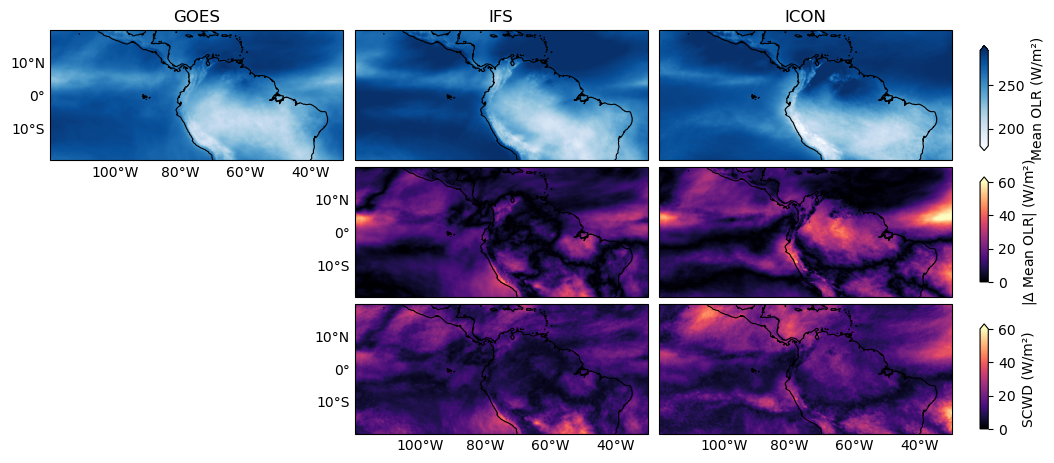

In [10]:
x_, y_ = scwd_maps['icon'].shape
x_slice = slice(x_//6,-1*x_//7)
y_slice = slice(y_//60,-1 * y_//11)
lon_min, lon_max = padded_lon[x_slice, y_slice][0][[0,-1]]
lat_min, lat_max = padded_lat[x_slice, y_slice][:,0][[0,-1]]

extent=[lon_min,lon_max, lat_min,lat_max]

fig, all_axs = plt.subplots(3, 3, figsize=(11.75, 3.5*1.5), subplot_kw={'projection': ccrs.PlateCarree()})

summaries = {}

axs = all_axs[0]

## plot likelihood maps in first row
vmin = 180
vmax = 290
for i, (olr_map, title) in enumerate(zip(
    [average_olr_maps['goes'], average_olr_maps['ifs'], average_olr_maps['icon']],
    ['GOES', 'IFS', 'ICON']
)):
    ax = axs[i]
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([-120, -30, -20, 20], crs=ccrs.PlateCarree())

    if i == 0:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

        ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
        ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W'])
        ax.tick_params(axis='x', length=0) 

    c = ax.imshow(olr_map[x_slice, y_slice], extent=extent, cmap='Blues', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title(title)


# Adjust spacing between subplots
fig.subplots_adjust(wspace=0.01, hspace=0.05)

# single colorbar for the second row
cbar_ax = fig.add_axes([0.92, 0.65, 0.007, 0.2])
cbar=fig.colorbar(c, cax=cbar_ax, label='Mean OLR (W/m²)', extend='both')

axs = all_axs[1]
vmin, vmax = 0, 60
for i, (olr_map, title) in enumerate(zip(
    [average_olr_maps['goes'], average_olr_maps['ifs'], average_olr_maps['icon']],
    ['GOES', 'IFS', 'ICON']
)):
    if title == 'GOES':
        # remove subplot
        axs[i].axis('off')
        continue
    ax = axs[i]
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([-120, -30, -20, 20], crs=ccrs.PlateCarree())

    if i == 1:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

    ax.tick_params(axis='x', length=0) 

    olr_bias_map = np.sqrt((olr_map - average_olr_maps['goes']) ** 2)
    c = ax.imshow(olr_bias_map[x_slice, y_slice], extent=extent, cmap='magma', vmin=vmin, vmax=vmax, origin='lower')

# Adjust spacing between subplots
fig.subplots_adjust(wspace=0.01, hspace=0.05)

cbar_ax = fig.add_axes([0.92, 0.4, 0.007, 0.2])
fig.colorbar(c, cax=cbar_ax, label=r'$|\Delta$ Mean OLR$|$ (W/m²)', extend='max')

axs = all_axs[2]

for i, (scwd_map, title) in enumerate(zip(
    [None, scwd_maps['ifs'], scwd_maps['icon']],
    ['GOES', 'IFS', 'ICON']
)):
    if title == 'GOES':
        # remove subplot
        axs[i].axis('off')
        continue
    ax = axs[i]
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([-120, -30, -20, 20], crs=ccrs.PlateCarree())

    if i == 1:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

    ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W'])
    ax.tick_params(axis='x', length=0) 

    key = 'icon' if 'ICON' in title else 'ifs'
    im = ax.imshow(scwd_map[x_slice, y_slice], extent=extent, cmap='magma', vmin=0, vmax=20, origin='lower')

cbar_ax = fig.add_axes([0.92, 0.12, 0.007, 0.2])
fig.colorbar(c, cax=cbar_ax, label=r'SCWD (W/m²)', extend='max')
plt.show()

In [11]:
from global_land_mask import globe

land_mask = globe.is_land(padded_lat[x_slice, y_slice], padded_lon[x_slice, y_slice])

for d_, scwd in scwd_maps.items():
    scwd = scwd[x_slice, y_slice]
    scwd_ocean = np.where(~land_mask, scwd, np.nan)    # keep ocean values
    scwd_land  = np.where(land_mask, scwd, np.nan)     # keep land values

    print(f'{d_}: mean scwd {np.nanmean(scwd):.3f}')
    print(f'{d_}: ocean scwd {np.nanmean(scwd_ocean):.3f}')
    print(f'{d_}: land scwd {np.nanmean(scwd_land):.3f}\n')

    olr_bias = np.sqrt((average_olr_maps[d_] - average_olr_maps['goes']) ** 2)[x_slice, y_slice]
    olr_bias_ocean  = np.where(~land_mask, olr_bias, np.nan) 
    olr_bias_land  = np.where(land_mask, olr_bias, np.nan) 
    print(f'{d_}: mae {np.nanmean(olr_bias):.3f}')
    print(f'{d_}: ocean mae {np.nanmean(olr_bias_ocean):.3f}')
    print(f'{d_}: land mae {np.nanmean(olr_bias_land):.3f}\n\n')

ifs: mean scwd 4.207
ifs: ocean scwd 4.390
ifs: land scwd 3.673

ifs: mae 11.124
ifs: ocean mae 11.583
ifs: land mae 9.787


icon: mean scwd 5.601
icon: ocean scwd 5.882
icon: land scwd 4.784

icon: mae 14.695
icon: ocean mae 14.522
icon: land mae 15.200


